In [11]:
df = pd.read_csv('Consumo_cerveja.csv')
display(df.head())

,Data,Temperatura Media (C),Temperatura Minima (C),Temperatura Maxima (C),Precipitacao (mm),Final de Semana,Consumo de cerveja (litros)
0,2015-01-01,"27,3","23,9","32,5",0,0.00,25.46
1,2015-01-02,"27,02","24,5","33,5",0,0.00,28.97
2,2015-01-03,"24,82","22,4","29,9",0,1.00,30.81
3,2015-01-04,"23,98","21,5","28,6","1,2",1.00,29.80
4,2015-01-05,"23,82",21,"28,3",0,0.00,28.90


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import zscore, pearsonr

pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [13]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

display(df.columns)

Index(['data', 'temperatura_media_(c)', 'temperatura_minima_(c)',
       'temperatura_maxima_(c)', 'precipitacao_(mm)', 'final_de_semana',
       'consumo_de_cerveja_(litros)'],
      dtype='object')

In [14]:
df['data'] = pd.to_datetime(df['data'], errors='coerce')

df['ano']       = df['data'].dt.year
df['mes']       = df['data'].dt.month
df['dia_semana'] = df['data'].dt.day_name()

display(df[['data', 'ano', 'mes', 'dia_semana']].head())

,data,ano,mes,dia_semana
0,2015-01-01,2015.00,1.00,Thursday
1,2015-01-02,2015.00,1.00,Friday
2,2015-01-03,2015.00,1.00,Saturday
3,2015-01-04,2015.00,1.00,Sunday
4,2015-01-05,2015.00,1.00,Monday


In [15]:
display(df.isnull().sum())
df = df.dropna()
print(f'\nRegistros após remoção de nulos: {len(df)}')

data                           576
temperatura_media_(c)          576
temperatura_minima_(c)         576
temperatura_maxima_(c)         576
precipitacao_(mm)              576
final_de_semana                576
consumo_de_cerveja_(litros)    576
ano                            576
mes                            576
dia_semana                     576
dtype: int64


Registros após remoção de nulos: 365


In [16]:
df['z_score'] = zscore(df['consumo_de_cerveja_(litros)'])

outliers = df[np.abs(df['z_score']) > 3]
print(f'Outliers encontrados: {len(outliers)}')
display(outliers)

df = df[np.abs(df['z_score']) <= 3].drop(columns=['z_score'])
print(f'Registros após remoção de outliers: {len(df)}')

Outliers encontrados: 0


,data,temperatura_media_(c),temperatura_minima_(c),temperatura_maxima_(c),precipitacao_(mm),final_de_semana,consumo_de_cerveja_(litros),ano,mes,dia_semana,z_score


Registros após remoção de outliers: 365


In [17]:
display(df['consumo_de_cerveja_(litros)'].describe())

media   = df['consumo_de_cerveja_(litros)'].mean()
mediana = df['consumo_de_cerveja_(litros)'].median()
desvio  = df['consumo_de_cerveja_(litros)'].std()

display(pd.DataFrame({
    'Métrica': ['Média', 'Mediana', 'Desvio Padrão'],
    'Valor':   [media, mediana, desvio]
}))

count   365.00
mean     25.40
std       4.40
min      14.34
25%      22.01
50%      24.87
75%      28.63
max      37.94
Name: consumo_de_cerveja_(litros), dtype: float64

,Métrica,Valor
0,Média,25.40
1,Mediana,24.87
2,Desvio Padrão,4.40


In [18]:
ordem_semana = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

consumo_dia = (
    df.groupby('dia_semana')['consumo_de_cerveja_(litros)']
    .agg(['mean', 'median', 'std'])
    .reindex(ordem_semana) 
)

display(consumo_dia.style.background_gradient(cmap='Blues'))

,mean,median,std
dia_semana,,,
Monday,23.609635,24.031000,3.350888
Tuesday,24.355154,24.025500,3.821638
Wednesday,23.810385,23.359500,4.110009
Thursday,24.076547,22.960000,4.037091
Friday,24.137885,24.477500,3.666590
Saturday,28.837923,29.334500,4.030173
Sunday,29.007519,29.592500,3.656695


In [19]:
consumo_mes = (
    df.groupby('mes')['consumo_de_cerveja_(litros)']
      .agg(['mean', 'sum'])
      .rename(columns={'mean': 'Média (L)', 'sum': 'Total (L)'})
)

styled = (
    consumo_mes.style
    .background_gradient(cmap='Oranges', subset=['Média (L)', 'Total (L)'])
    .format({'Média (L)': '{:.1f}', 'Total (L)': '{:,.0f}'})
    .bar(subset=['Total (L)'], color='#FF8C00', vmin=0)
    .set_caption('Consumo de Cerveja por Mês')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '16px'), ('font-weight', 'bold')]
    }])
)

display(styled)

,Média (L),Total (L)
mes,,
1.000000,28.7,889
2.000000,25.7,719
3.000000,25.0,776
4.000000,24.6,739
5.000000,22.8,707
6.000000,23.6,709
7.000000,22.6,700
8.000000,25.9,803
9.000000,25.2,756


In [20]:
df_clean = df.dropna(subset=['temperatura_media_(c)', 'consumo_de_cerveja_(litros)'])

if len(df_clean) < 2:
    print('Dados insuficientes para calcular correlação (menos de 2 pontos válidos).')
else:
    corr_temp, p_valor = pearsonr(
        df_clean['temperatura_media_(c)'],
        df_clean['consumo_de_cerveja_(litros)']
    )

    display(pd.DataFrame({
        'Correlação com Temperatura': [round(corr_temp, 3)],
        'P-valor':                    [round(p_valor, 4)]
    }))

    significancia = 'estatisticamente significativa (p < 0.05)' if p_valor < 0.05 \
                    else 'NÃO estatisticamente significativa (p >= 0.05)'
    print(f'A correlação é {significancia}.')

AttributeError: 'numpy.dtypes.ObjectDType' object has no attribute 'dtype'

In [21]:

col_temp    = pd.to_numeric(df['temperatura_media_(c)'], errors='coerce').astype('float64')
col_consumo = pd.to_numeric(df['consumo_de_cerveja_(litros)'], errors='coerce').astype('float64')


df_clean = pd.DataFrame({
    'temperatura_media_(c)':       col_temp,
    'consumo_de_cerveja_(litros)': col_consumo
}).dropna()

print(f"Dtype temperatura : {df_clean['temperatura_media_(c)'].dtype}")
print(f"Dtype consumo     : {df_clean['consumo_de_cerveja_(litros)'].dtype}")
print(f"Linhas válidas    : {len(df_clean)}")

if len(df_clean) < 2:
    print('Dados insuficientes para calcular correlação.')
else:
    corr_temp, p_valor = pearsonr(
        df_clean['temperatura_media_(c)'].values,   
        df_clean['consumo_de_cerveja_(litros)'].values
    )

    display(pd.DataFrame({
        'Correlação com Temperatura': [round(corr_temp, 3)],
        'P-valor':                    [round(p_valor, 4)]
    }))

    significancia = 'estatisticamente significativa (p < 0.05)' if p_valor < 0.05 \
                    else 'NÃO estatisticamente significativa (p >= 0.05)'
    print(f'A correlação é {significancia}.')

Dtype temperatura : float64
Dtype consumo     : float64
Linhas válidas    : 9


,Correlação com Temperatura,P-valor
0,0.49,0.18


A correlação é NÃO estatisticamente significativa (p >= 0.05).


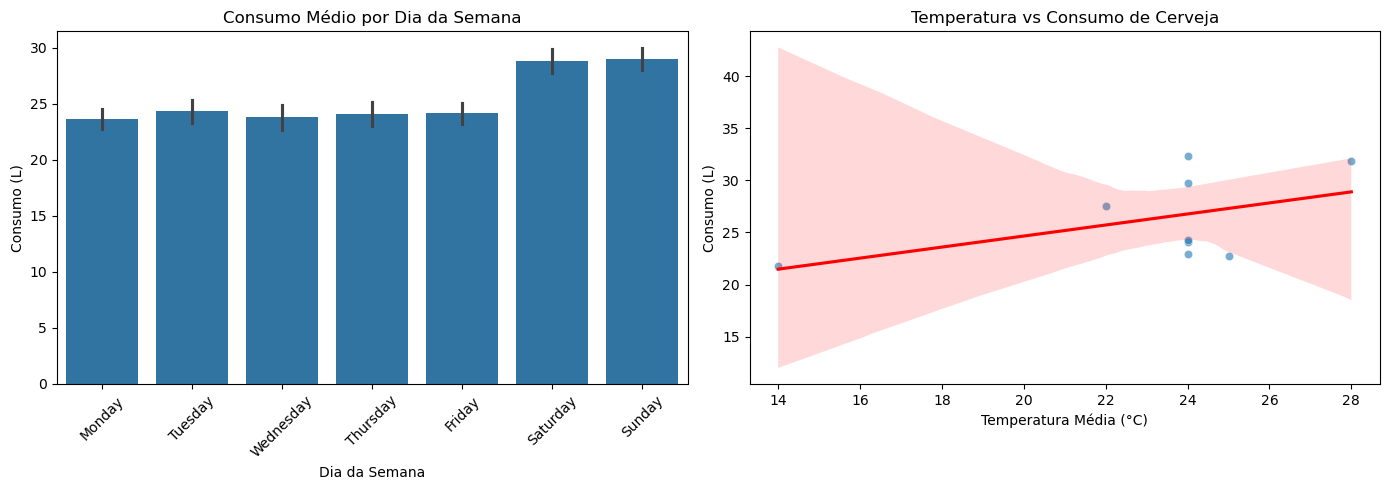

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=df,
    x='dia_semana',
    y='consumo_de_cerveja_(litros)',
    order=ordem_semana,
    ax=axes[0]
)
axes[0].set_title('Consumo Médio por Dia da Semana')
axes[0].set_xlabel('Dia da Semana')
axes[0].set_ylabel('Consumo (L)')
axes[0].tick_params(axis='x', rotation=45)

sns.scatterplot(
    data=df_clean,
    x='temperatura_media_(c)',
    y='consumo_de_cerveja_(litros)',
    ax=axes[1],
    alpha=0.6
)
sns.regplot(
    data=df_clean,
    x='temperatura_media_(c)',
    y='consumo_de_cerveja_(litros)',
    scatter=False,
    ax=axes[1],
    color='red'
)
axes[1].set_title('Temperatura vs Consumo de Cerveja')
axes[1].set_xlabel('Temperatura Média (°C)')
axes[1].set_ylabel('Consumo (L)')

plt.tight_layout()
plt.show()